In [1]:
import os, sys, importlib, pathlib
import pandas as pd
from pathlib import Path
sys.path.append (os.path.abspath(".."))

In [64]:
path_df="../data_processed\paris_2406\listings_processed_paris_2406_62738.csv"
# path_df="../data_processed\london_2406\listings_processed_london_2406_49856.csv"
df=pd.read_csv(path_df)
df['time']="2406"
df["in_paris"]=1
print(df[['in_paris','time']].value_counts())



in_paris  time
1         2406    62738
Name: count, dtype: int64


In [65]:
df.lang.value_counts()
df.rename(columns={'len':'text_length'}, inplace=True)
df.text_length.isna().value_counts()
df.text_length.describe()

count    62738.000000
mean        25.458861
std         51.375488
min          0.000000
25%          0.000000
50%          0.000000
75%         34.000000
max        915.000000
Name: text_length, dtype: float64

In [66]:
df['has_text']=df['lang'].apply(lambda x : 0 if x=="no_text" else 1)
df['lang_fr']=df['lang'].apply(lambda x : 1 if x=="fr" else 0)
df['lang_en']=df['lang'].apply(lambda x : 1 if x=="en" else 0)

In [67]:
df.to_csv(path_df, index=False)

In [81]:
DATA_DIR='../data_processed'
groups=[   
    'london_2306', "london_2309", "london_2312","london_2403",'london_2406',
    'paris_2306', "paris_2309", "paris_2312","paris_2403","paris_2406"
]

list_df=[]
for i,group in enumerate(groups):
    df_dir=os.path.join(DATA_DIR, group)
    path_df=os.path.join(df_dir, [f for f in os.listdir(df_dir) if f.startswith("listings_processed")][0])
    print(path_df)

    df=pd.read_csv(path_df)
    print(f"{i}-{group}:{df.shape}\n")
   
    # check:
    # print(group)
    # print(df.in_paris.value_counts())
    # print(df.time.value_counts(),"\n")
    list_df.append(df)

df_pre=pd.concat(list_df, axis=0)
print(df_pre.shape)
print(df_pre[['in_paris','time']].value_counts(dropna=False))

../data_processed\london_2306\listings_processed_london_2306.csv
0-london_2306:(42356, 91)

../data_processed\london_2309\listings_processed_london_2309.csv
1-london_2309:(42393, 90)

../data_processed\london_2312\listings_processed_london_2312.csv
2-london_2312:(43172, 90)

../data_processed\london_2403\listings_processed_london_2403.csv
3-london_2403:(44958, 90)

../data_processed\london_2406\listings_processed_london_2406_49856.csv
4-london_2406:(49856, 92)

../data_processed\paris_2306\listings_processed_paris_2306.csv


C:\Users\yeliu\AppData\Local\Temp\ipykernel_13292\3325578416.py:13: DtypeWarning: Columns (59,60) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(path_df)


5-paris_2306:(32901, 91)

../data_processed\paris_2309\listings_processed_paris_2309.csv
6-paris_2309:(31555, 90)

../data_processed\paris_2312\listings_processed_paris_2312.csv
7-paris_2312:(35829, 92)

../data_processed\paris_2403\listings_processed_paris_2403.csv
8-paris_2403:(40865, 90)

../data_processed\paris_2406\listings_processed_paris_2406_62738.csv
9-paris_2406:(62738, 91)

(426623, 93)
in_paris  time
1         2406    62738
0         2406    49856
          2403    44958
          2312    43172
          2309    42393
          2306    42356
1         2403    40865
          2312    35829
          2306    32901
          2309    31555
Name: count, dtype: int64


In [ ]:
# df[["has_text","lang_fr",'lang_en']].isna().value_counts(dropna=False)
# df.text_length.isna().value_counts(dropna=False)
# df[df['has_text'].isna()][['in_paris','time']].value_counts()
# df.lang.value_counts()

Series([], Name: count, dtype: int64)

In [ ]:
# 我们要估计：不同时点，Paris 相对于 London 的差异变化

# 重点看：
# pre-period（2309, 2312）系数是否 ≈ 0 → parallel trend
# post（2406）是否显著 → 奥运影响

import pandas as pd

df = df_pre.copy()

# 把 time 转成分类变量
df['time'] = df['time'].astype(str)

# 设定 baseline（reference period）
# 2306 作为基准，不进入回归


# df.time.value_counts(dropna=False)

import statsmodels.formula.api as smf
formula=("booking_rate_l90d ~" 
        "C(host_identity_verified)  + review_scores_rating + has_rating +"
        "number_of_reviews_ltm + "
        "C(host_is_superhost) +"
        "years_since_host + professional_host + "
        "host_response_rate +  +C(host_response_time)+"
        "has_text + lang_en + lang_fr + text_length+"
        "price   + C(room_type) + C(instant_bookable) + availability_90+"
        "in_paris * C(time) "
        # "in_paris * in_2024 "
)

# formula=(
#     "booking_rate_l90d ~ "
#     "C(host_identity_verified)  + review_scores_rating + has_rating +"
#     "number_of_reviews_ltm + "
#     "C(host_is_superhost) +"
#     "years_since_host + professional_host + "
#     "host_response_rate +  +C(host_response_time)+"
#     # "has_text + "
#     "lang_en + lang_fr + text_length + "
#     "C(time)*in_paris"
# )

formula='booking_rate_l90d ~ C(time)*in_paris'
model = smf.ols(
    formula,    
    data=df
).fit(cov_type='cluster', cov_kwds={'groups': df['in_paris']})

print(model.summary())

## 交互项显著,平行趋势不成立!

                            OLS Regression Results                            
Dep. Variable:      booking_rate_l90d   R-squared:                       0.040
Model:                            OLS   Adj. R-squared:                  0.040
Method:                 Least Squares   F-statistic:                 1.990e+23
Date:                Sun, 05 Apr 2026   Prob (F-statistic):           1.59e-12
Time:                        20:59:53   Log-Likelihood:                 19223.
No. Observations:              426623   AIC:                        -3.843e+04
Df Residuals:                  426613   BIC:                        -3.832e+04
Df Model:                           9                                         
Covariance Type:              cluster                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

d:\miniconda3\envs\airbnb_env\lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 9, but rank is 2
  warnings.warn('covariance of constraints does not have full '


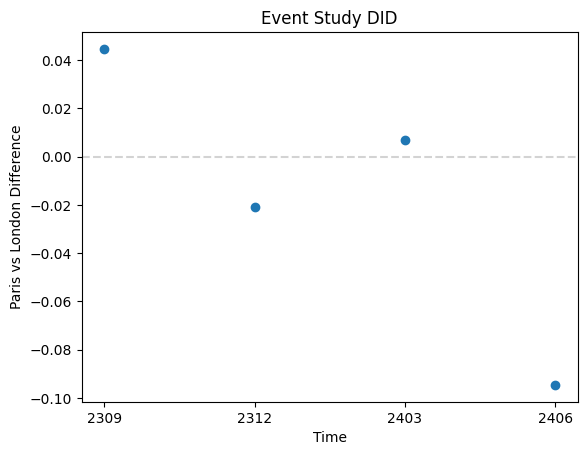

In [ ]:
# 检查趋势差异的大小
## 加不加控制变量，差距不大
import matplotlib.pyplot as plt

coefs = model.params.filter(like=':in_paris')
errors = model.bse.filter(like=':in_paris')

times = ['2309', '2312', "2403", '2406']

plt.errorbar(times, coefs, yerr=1.96*errors, fmt='o')
plt.axhline(0,linestyle='--', color="lightgray")
plt.title('Event Study DID')
plt.xlabel('Time')
plt.ylabel('Paris vs London Difference')
plt.show()

## 应该尽可能靠近0，且差距不显著。parallel显然不成立！

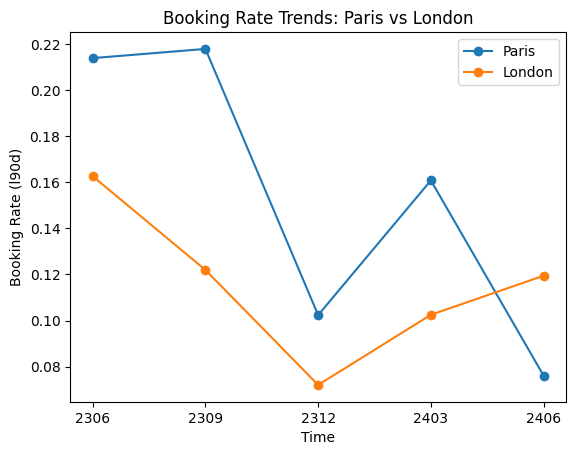

In [ ]:
# 检查两地预订率的变化,每个时间点的垂直距离代表差异,对应线之间斜率差代表趋势差异,对应交互项

import matplotlib.pyplot as plt

avg = df.groupby(['time', 'in_paris'])['booking_rate_l90d'].mean().reset_index()

# pivot 成两列
pivot = avg.pivot(index='time', columns='in_paris', values='booking_rate_l90d')

plt.plot(pivot.index, pivot[1], marker='o', label='Paris')
plt.plot(pivot.index, pivot[0], marker='o', label='London')

# plt.axvline('2406', linestyle='--', color='gray')  # treatment time

plt.title('Booking Rate Trends: Paris vs London')
plt.xlabel('Time')
plt.ylabel('Booking Rate (l90d)')
plt.legend()
plt.show()

## trend

In [109]:
df_pre.time.value_counts()
df_pre.time.dtype

dtype('int64')

In [114]:
# in_paris * post : 奥运会对 Paris 的因果影响（DID effect）
# t * in_paris: 允许 Paris 有一条“自己的趋势线”，不和lonodn保持parallel
# C(time) 控制季节，宏观变化


# C(time)：控制整体时间变化（季节、宏观要素）
# t*in_paris：显示 Paris 和 London 有不同趋势.构建连续变量t，代表时间发展，（已知paris和london发展趋势不平行），通过t:in_paris的交互项提取处代表paris/london的之间的trend heterogeneity
## 负值说明了每往后一个时间点，Paris 相对 London 多下降 0.0042（下降更快）
# 控制city trend之后，in_paris:post识别奥运的额外冲击

df=df_pre[df_pre['time'].isin([2306, 2312,2406])].copy()
print(df.shape)
df['time'] = df['time'].astype(str)
df['t'] = df['time'].map({'2306':0, "2312":1, '2406':2})
# df['t'] = df['time'].map({'2306':0, '2309':1, '2312':2, '2403':3,'2406':4})
df['post']=df['time'].apply(lambda x : 1 if x=='2406' else 0)

print(df[['t','post']].value_counts())
model = smf.ols(
    'booking_rate_l90d ~ in_paris*post + t*in_paris + C(time)',
    data=df
).fit()
print(model.summary())

(266852, 93)
t  post
2  1       112594
1  0        79001
0  0        75257
Name: count, dtype: int64
                            OLS Regression Results                            
Dep. Variable:      booking_rate_l90d   R-squared:                       0.044
Model:                            OLS   Adj. R-squared:                  0.044
Method:                 Least Squares   F-statistic:                     1773.
Date:                Sun, 05 Apr 2026   Prob (F-statistic):               0.00
Time:                        22:21:36   Log-Likelihood:                 26439.
No. Observations:              266852   AIC:                        -5.286e+04
Df Residuals:                  266844   BIC:                        -5.278e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-------------------------

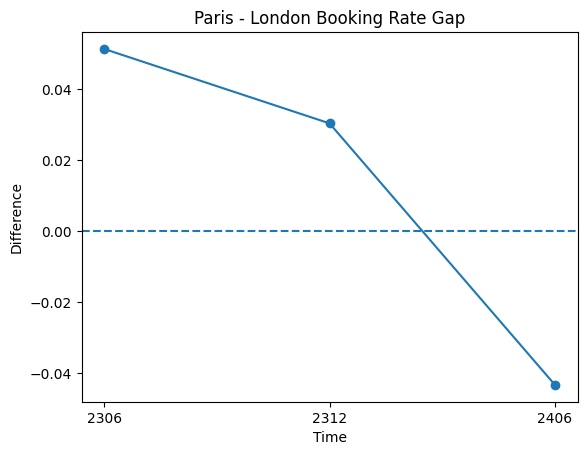

In [115]:
import pandas as pd
import matplotlib.pyplot as plt

# 计算每个时间点的均值
avg = df.groupby(['time', 'in_paris'])['booking_rate_l90d'].mean().reset_index()

pivot = avg.pivot(index='time', columns='in_paris', values='booking_rate_l90d')

# 计算差值
pivot['gap'] = pivot[1] - pivot[0]

plt.plot(pivot.index, pivot['gap'], marker='o')

plt.axhline(0, linestyle='--')
# plt.axvline('2406', linestyle='--', color='gray')

plt.title('Paris - London Booking Rate Gap')
plt.xlabel('Time')
plt.ylabel('Difference')

plt.show()

In [90]:
# 👉 解释：允许 Paris 有自己的趋势
# 控制掉 pre-trend 差异

# 方案 2：只用临近窗口（简单但有效）
# 只用：
# 2312（pre）
# 2406（post）

# df=df_pre[df_pre['time'].isin(['2312', "2406"])].copy()
df=df_pre.copy()

print(df.shape)
print(df[['in_paris', 'time']].value_counts())


# df['t'] = df['time'].map({'2306':0, '2309':1, '2312':2, '2406':3})
df['t'] = df['time'].map({'2306':0, '2309':1, '2312':2, '2403':3,'2406':4})
df['post']=df['time'].apply(lambda x : 1 if x=='2406' else 0)


model = smf.ols(
    'booking_rate_l90d ~ in_paris*post + t*in_paris + C(time)',
    data=df
).fit()
print(model.summary())

(426623, 93)
in_paris  time
1         2406    62738
0         2406    49856
          2403    44958
          2312    43172
          2309    42393
          2306    42356
1         2403    40865
          2312    35829
          2306    32901
          2309    31555
Name: count, dtype: int64


ValueError: zero-size array to reduction operation maximum which has no identity

In [ ]:
df['t'] = df['time'].map({'2306':0, '2309':1, '2312':2, '2406':3})
model = smf.ols(
    'booking_rate_l90d ~ in_paris*post + t*in_paris + C(time)',
    data=df
).fit()

In [ ]:
# 如果平行趋势 OK：标准 DID（用于报告）
df['post'] = (df['time'] == '2406').astype(int)
model_did = smf.ols(
    'booking_rate_l90d ~ in_paris*post + C(time)',
    data=df
).fit()

print(model_did.summary())

                            OLS Regression Results                            
Dep. Variable:      booking_rate_l90d   R-squared:                       0.044
Model:                            OLS   Adj. R-squared:                  0.044
Method:                 Least Squares   F-statistic:                     2629.
Date:                Sun, 05 Apr 2026   Prob (F-statistic):               0.00
Time:                        20:15:49   Log-Likelihood:                 16719.
No. Observations:              340800   AIC:                        -3.342e+04
Df Residuals:                  340793   BIC:                        -3.335e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.1571      0.001    1

In [21]:
print(df_pre.time.dtype)

float64


In [ ]:
import statsmodels.formula.api as smf
df=df_pre.copy()
df['time_i']=df["time"].apply(lambda x : 0 if x==2306 else( 1 if x==2309 else 2))

print(df[['in_paris','time', "time_i"]].value_counts())
print(df.shape)

formula= ("booking_rate_l90d ~" 
        # "C(host_identity_verified)  + review_scores_rating + has_rating +"
        # "number_of_reviews_ltm + "
        # "C(host_is_superhost) +"
        # "years_since_host + professional_host + "
        # "host_response_rate +  +C(host_response_time)+"
        # "has_text + lang_en + lang_fr + text_length+"
        # "price   + C(room_type) + C(instant_bookable) + availability_90+"
        "in_paris * time_i +  time_i"
        # "in_paris * in_2024 "
)

# formula = """
# booking_rate_l90d ~ 
#     in_paris * C(time)
#     + price
#     + availability_90
#     + number_of_reviews_ltm
#     + host_response_rate
#     + has_text
#     + text_length
# """

model = smf.ols(
    formula,
    data=df
).fit()
# cov_type='cluster', cov_kwds={'groups': df['listing_id']}
print(model.summary())

in_paris  time  time_i
0         2312  2         43172
          2309  1         42393
          2306  0         42356
1         2312  2         35829
          2306  0         32901
          2309  1         31555
Name: count, dtype: int64
(228206, 93)
                            OLS Regression Results                            
Dep. Variable:      booking_rate_l90d   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.039
Method:                 Least Squares   F-statistic:                     3083.
Date:                Sun, 05 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:19:47   Log-Likelihood:                -6839.4
No. Observations:              228206   AIC:                         1.369e+04
Df Residuals:                  228202   BIC:                         1.373e+04
Df Model:                           3                                         
Covariance Type:            nonrobu